# Metrics Exploration Notebook

This notebook reproduces the analysis using the results.


In [1]:
from pathlib import Path

import pandas as pd

import analyse as an
import plots as pl

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

ROOT = Path(".").resolve()
FIGURES_DIR = ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

metric_titles = {
    "overall_accuracy": "Overall Accuracy",
    "macro_level_accuracy": "Level-Balanced Accuracy",
    "baseline_hardness_weighted_accuracy": "Baseline-Hardness Weighted Accuracy",
    "hardest_level_accuracy": "Level 5 Accuracy",
    "average_solved_difficulty": "Average Solved Difficulty",
}

run_metric_columns = [
    "run_label",
    "strategy",
    "reward",
    "overall_accuracy",
    "delta_vs_baseline",
    "macro_level_accuracy",
    "baseline_hardness_weighted_accuracy",
    "hardest_level_accuracy",
    "average_solved_difficulty",
]

grid_metric_names = [
    "overall_accuracy",
    "macro_level_accuracy",
    "baseline_hardness_weighted_accuracy",
    "hardest_level_accuracy",
    "average_solved_difficulty",
]

reward_colors = {
    "baseline": "#5c677d",
    "binary": "#2a9d8f",
    "easy_penalty": "#e76f51",
    "difficulty_weighted": "#264653",
}

strategy_markers = {
    "baseline": "o",
    "curriculum": "s",
    "random": "^",
    "stratified": "D",
}

label_replacements = {
    "Curriculum": "Curric.",
    "Stratified": "Strat.",
    "Difficulty Weighted": "Diff. Wtd.",
    "Easy Penalty": "Easy Pen.",
}


def pretty(text: str) -> str:
    return "Baseline" if text == "baseline" else an.title_case(text)


def short_label(text: str) -> str:
    return pl.compact_text(text, label_replacements)


pl.set_plot_style()
runs, levels = an.load_results(ROOT)
metrics = an.compute_run_metrics(runs, levels)
strategy_summary = an.summarize_dimension(metrics, "strategy")
reward_summary = an.summarize_dimension(metrics, "reward")

metrics.sort_values("overall_accuracy", ascending=False)


,run_name,run_label,strategy,reward,overall_accuracy,delta_vs_baseline,macro_level_accuracy,baseline_hardness_weighted_accuracy,hardest_level_accuracy,average_solved_difficulty,difficulty_drop
0,output-curriculum-binary_20260315_114944,Curriculum + Binary,curriculum,binary,0.442,0.038,0.50414,0.435228,0.1791,2.895928,0.6116
1,output-stratified-binary_20260314_183029,Stratified + Binary,stratified,binary,0.438,0.034,0.50216,0.431830,0.1716,2.894977,0.6424
2,output-stratified-easy_penalty_20260315_092237,Stratified + Easy Penalty,stratified,easy_penalty,0.436,0.032,0.50220,0.430772,0.1791,2.871560,0.6349
3,output-stratified-difficulty_weighted_20260314...,Stratified + Difficulty Weighted,stratified,difficulty_weighted,0.432,0.028,0.48846,0.428169,0.2239,2.972222,0.5435
4,output-curriculum-easy_penalty_20260315_165208,Curriculum + Easy Penalty,curriculum,easy_penalty,0.430,0.026,0.48792,0.424131,0.1866,2.934884,0.5808
5,output-random-easy_penalty_20260313_203642,Random + Easy Penalty,random,easy_penalty,0.430,0.026,0.49542,0.423216,0.1567,2.874419,0.6573
6,output-random-difficulty_weighted_20260314_201224,Random + Difficulty Weighted,random,difficulty_weighted,0.428,0.024,0.48648,0.424004,0.2090,2.939252,0.5584
7,output-random-binary_20260313,Random + Binary,random,binary,0.422,0.018,0.48750,0.418457,0.1866,2.890995,0.6274
8,output-curriculum-difficulty_weighted_20260315...,Curriculum + Difficulty Weighted,curriculum,difficulty_weighted,0.418,0.014,0.47746,0.413671,0.1940,2.923445,0.5734
9,Qwen2.5-1.5B-Instruct_20260302_114548,Baseline,baseline,baseline,0.404,0.000,0.45890,0.398158,0.1716,2.925743,0.5493


## Metric Reference

- `Overall Accuracy`: total correct divided by total questions.
- `Level-Balanced Accuracy`: mean of the five level accuracies, which normalizes away unequal question counts.
- `Baseline-Hardness Weighted Accuracy`: weighted mean using `1 - baseline_accuracy(level)`.
- `Average Solved Difficulty`: average level number of solved questions. With levels `1..5`, it typically ranges from `1` to `5` when at least one question is solved.


In [2]:
metrics[run_metric_columns].sort_values("overall_accuracy", ascending=False)


,run_label,strategy,reward,overall_accuracy,delta_vs_baseline,macro_level_accuracy,baseline_hardness_weighted_accuracy,hardest_level_accuracy,average_solved_difficulty
0,Curriculum + Binary,curriculum,binary,0.442,0.038,0.50414,0.435228,0.1791,2.895928
1,Stratified + Binary,stratified,binary,0.438,0.034,0.50216,0.431830,0.1716,2.894977
2,Stratified + Easy Penalty,stratified,easy_penalty,0.436,0.032,0.50220,0.430772,0.1791,2.871560
3,Stratified + Difficulty Weighted,stratified,difficulty_weighted,0.432,0.028,0.48846,0.428169,0.2239,2.972222
4,Curriculum + Easy Penalty,curriculum,easy_penalty,0.430,0.026,0.48792,0.424131,0.1866,2.934884
5,Random + Easy Penalty,random,easy_penalty,0.430,0.026,0.49542,0.423216,0.1567,2.874419
6,Random + Difficulty Weighted,random,difficulty_weighted,0.428,0.024,0.48648,0.424004,0.2090,2.939252
7,Random + Binary,random,binary,0.422,0.018,0.48750,0.418457,0.1866,2.890995
8,Curriculum + Difficulty Weighted,curriculum,difficulty_weighted,0.418,0.014,0.47746,0.413671,0.1940,2.923445
9,Baseline,baseline,baseline,0.404,0.000,0.45890,0.398158,0.1716,2.925743


## Level Distribution and Baseline Hardness

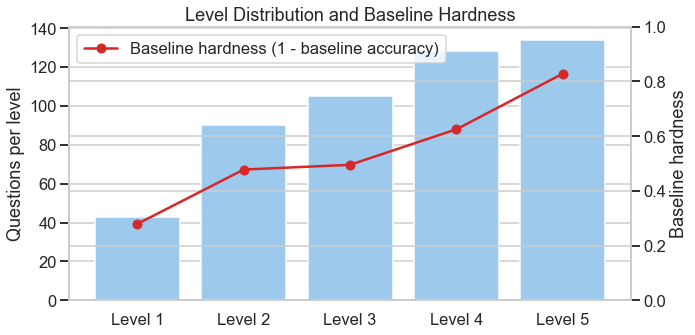

In [3]:
baseline_plot_title = "Level Distribution and Baseline Hardness"

baseline_profile = an.baseline_profile(levels)

pl.plot_dual_axis_bar_line(
    baseline_profile,
    x_col="level_label",
    bar_col="total",
    line_col="baseline_hardness",
    title=baseline_plot_title,
    bar_y_label="Questions per level",
    line_y_label="Baseline hardness",
    line_label="Baseline hardness (1 - baseline accuracy)",
    line_ylim=(0, max(1.0, baseline_profile["baseline_hardness"].max() * 1.15)),
    save_dir=FIGURES_DIR,
)


## Strategy and Reward Summaries

In [4]:
strategy_summary

,strategy,overall_accuracy,macro_level_accuracy,baseline_hardness_weighted_accuracy,hardest_level_accuracy,average_solved_difficulty,delta_vs_baseline
0,stratified,0.435333,0.497607,0.430257,0.191533,2.912920,0.031333
1,curriculum,0.430000,0.489840,0.424343,0.186567,2.918085,0.026000
2,random,0.426667,0.489800,0.421892,0.184100,2.901555,0.022667


In [5]:
reward_summary

,reward,overall_accuracy,macro_level_accuracy,baseline_hardness_weighted_accuracy,hardest_level_accuracy,average_solved_difficulty,delta_vs_baseline
0,binary,0.434,0.497933,0.428505,0.179100,2.893967,0.030
1,easy_penalty,0.432,0.495180,0.426040,0.174133,2.893621,0.028
2,difficulty_weighted,0.426,0.484133,0.421948,0.208967,2.944973,0.022


## Overall Ranking

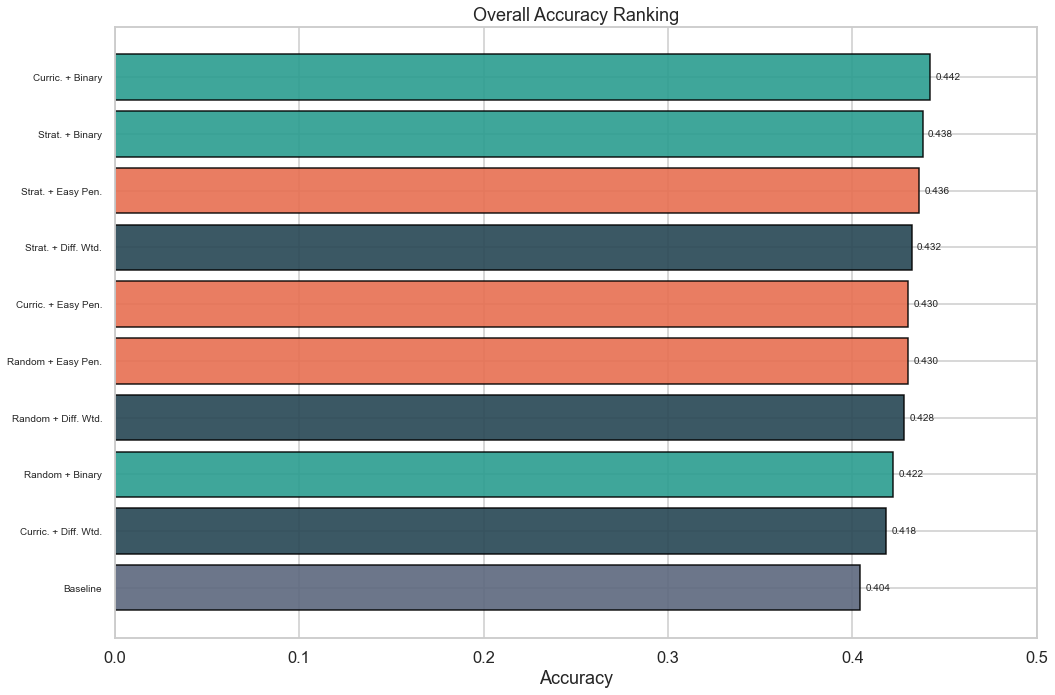

In [6]:
ranking_title = "Overall Accuracy Ranking"

overall_ranking = (
    metrics.sort_values("overall_accuracy", ascending=False)
    .assign(plot_label=lambda frame: frame["run_label"].map(short_label))
)

pl.plot_horizontal_bars(
    overall_ranking,
    label_col="plot_label",
    value_col="overall_accuracy",
    color_col="reward",
    color_map=reward_colors,
    title=ranking_title,
    x_label="Accuracy",
    xlim=(0, max(0.5, overall_ranking["overall_accuracy"].max() * 1.12)),
    save_dir=FIGURES_DIR,
)


## Strategy x Reward Metric Grid

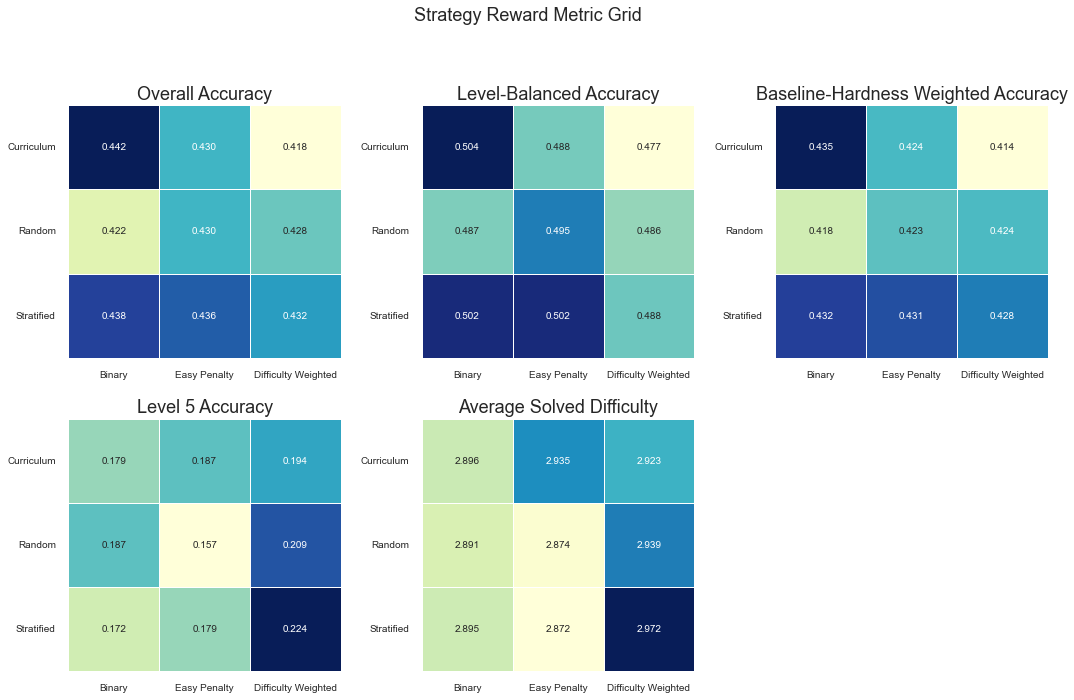

In [7]:
grid_title = "Strategy Reward Metric Grid"

interaction_data = (
    metrics.loc[metrics["strategy"] != "baseline"]
    .copy()
    .assign(
        strategy=lambda frame: frame["strategy"].astype(str).map(an.title_case),
        reward=lambda frame: frame["reward"].astype(str).map(an.title_case),
    )
)

pl.plot_metric_grid(
    interaction_data,
    metric_names=grid_metric_names,
    metric_titles=metric_titles,
    index_col="strategy",
    column_col="reward",
    index_order=[an.title_case(name) for name in an.STRATEGY_ORDER[1:]],
    column_order=[an.title_case(name) for name in an.REWARD_ORDER[1:]],
    title=grid_title,
    save_dir=FIGURES_DIR,
)


## Level-Wise Accuracy and Factor-Level Maps


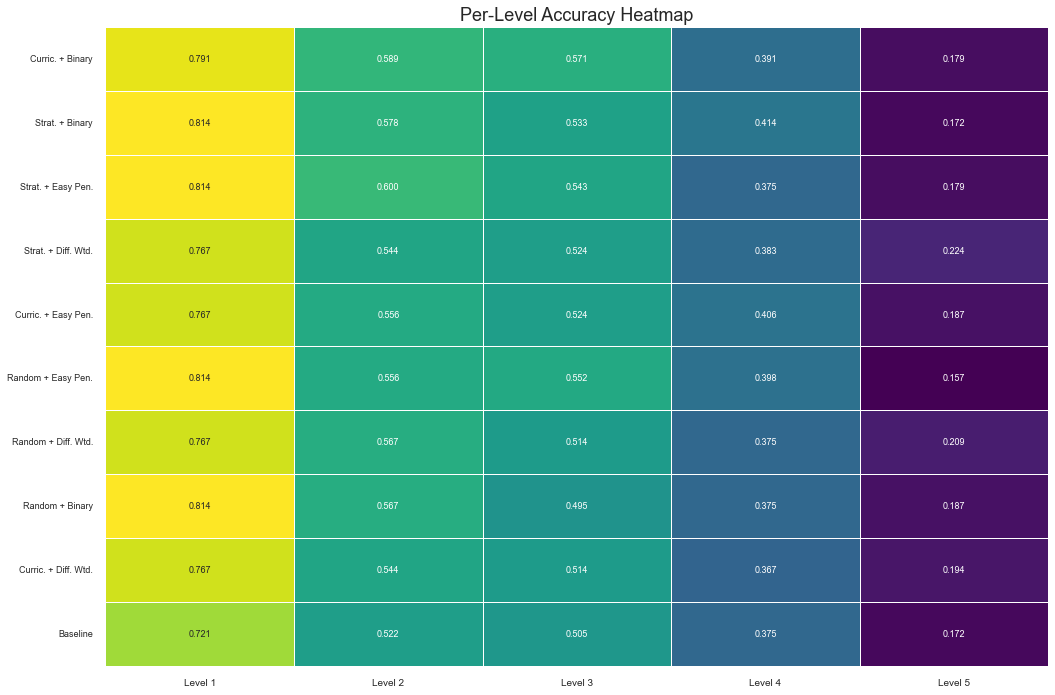

In [8]:
level_heatmap_title = "Per-Level Accuracy Heatmap"

level_accuracy_pivot = pl.build_pivot_table(
    levels,
    index_col="run_label",
    column_col="level_label",
    value_col="accuracy",
    index_order=metrics.sort_values("overall_accuracy", ascending=False)["run_label"].tolist(),
    column_order=an.LEVEL_LABELS,
    index_transform=short_label,
)

pl.plot_heatmap(
    level_accuracy_pivot,
    title=level_heatmap_title,
    cmap="viridis",
    save_dir=FIGURES_DIR,
)


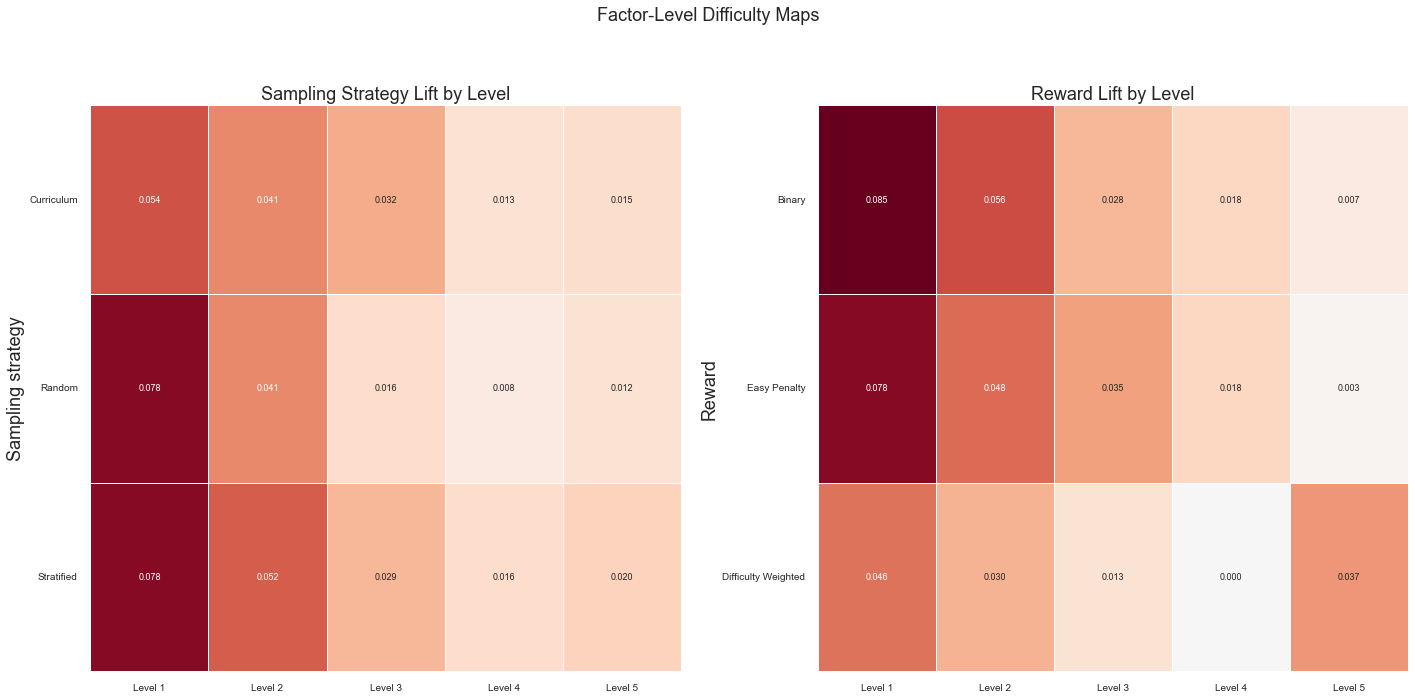

In [9]:
maps_title = "Factor-Level Difficulty Maps"

strategy_level_summary = (
    an.summarize_levels_by_dimension(levels, "strategy")
    .assign(strategy=lambda frame: frame["strategy"].astype(str).map(an.title_case))
)
reward_level_summary = (
    an.summarize_levels_by_dimension(levels, "reward")
    .assign(reward=lambda frame: frame["reward"].astype(str).map(an.title_case))
)

strategy_map = pl.build_pivot_table(
    strategy_level_summary,
    index_col="strategy",
    column_col="level_label",
    value_col="delta_vs_baseline",
    index_order=[an.title_case(name) for name in an.STRATEGY_ORDER[1:]],
    column_order=an.LEVEL_LABELS,
)
reward_map = pl.build_pivot_table(
    reward_level_summary,
    index_col="reward",
    column_col="level_label",
    value_col="delta_vs_baseline",
    index_order=[an.title_case(name) for name in an.REWARD_ORDER[1:]],
    column_order=an.LEVEL_LABELS,
)

lift_limit = max(
    float(strategy_map.abs().max().max()),
    float(reward_map.abs().max().max()),
)

pl.plot_heatmap_panels(
    [
        {
            "data": strategy_map,
            "title": "Sampling Strategy Lift by Level",
            "y_label": "Sampling strategy",
        },
        {
            "data": reward_map,
            "title": "Reward Lift by Level",
            "y_label": "Reward",
        },
    ],
    title=maps_title,
    cmap="RdBu_r",
    center=0.0,
    vmin=-lift_limit,
    vmax=lift_limit,
    save_dir=FIGURES_DIR,
)


## Difficulty Shape by Reward

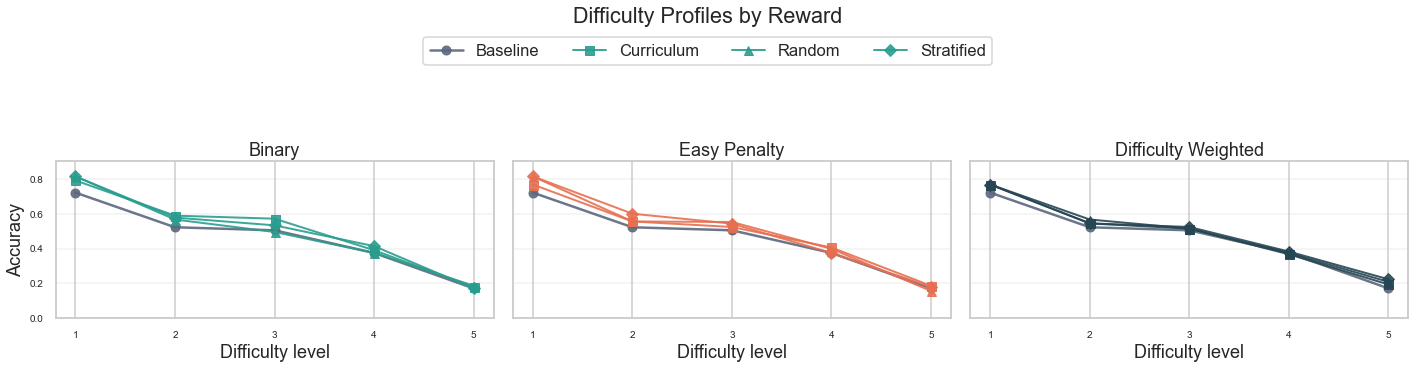

In [10]:
profile_title = "Difficulty Profiles by Reward"

baseline_profile_lines = an.baseline_profile(levels)[
    ["level_number", "level_label", "accuracy"]
]

profile_frames = []
for reward in an.REWARD_ORDER[1:]:
    profile_frames.append(
        baseline_profile_lines.assign(reward_panel=reward, strategy_key="baseline")
    )
    for strategy in an.STRATEGY_ORDER[1:]:
        profile_frames.append(
            levels.loc[
                (levels["reward"] == reward) & (levels["strategy"] == strategy),
                ["level_number", "level_label", "accuracy"],
            ]
            .sort_values("level_number")
            .assign(reward_panel=reward, strategy_key=strategy)
        )

profile_data = pd.concat(profile_frames, ignore_index=True)

pl.plot_panel_lines(
    profile_data,
    panel_col="reward_panel",
    x_col="level_number",
    y_col="accuracy",
    series_col="strategy_key",
    title=profile_title,
    panel_order=an.REWARD_ORDER[1:],
    series_order=an.STRATEGY_ORDER,
    panel_colors=reward_colors,
    series_markers=strategy_markers,
    panel_label_fn=pretty,
    series_label_fn=pretty,
    highlight_series={
        "baseline": {"color": reward_colors["baseline"], "linewidth": 2.5}
    },
    y_label="Accuracy",
    x_label="Difficulty level",
    x_ticks=baseline_profile_lines["level_number"].tolist(),
    y_limits=(0.0, 0.9),
    save_dir=FIGURES_DIR,
)


## Level Winners

In [11]:
an.build_level_winners(levels)

,Level,Winning Run(s),Winning Accuracy,Delta vs Baseline
0,Level 1,"Random + Binary, Random + Easy Penalty, Strati...",0.8140,0.0931
1,Level 2,Stratified + Easy Penalty,0.6000,0.0778
2,Level 3,Curriculum + Binary,0.5714,0.0666
3,Level 4,Stratified + Binary,0.4141,0.0391
4,Level 5,Stratified + Difficulty Weighted,0.2239,0.0523
